### Tarea 3: PSO

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. PSO con 2 variables y restricciones

### 3.1 Definición del problema

**Código de clase.** Maximizar

$$Z = 16.9175\,X_1 + 22.715\,X_2$$

sujeto a $100X_1+150X_2 \le 12000$, $20X_1+30X_2 \le 3000$, $25X_1+40X_2 \le 3000$,
$X_2 \ge 30$, $X_1 \ge 0$, $X_2 \ge 0$.

Es lineal, así que el óptimo está en un vértice y se puede verificar a mano: la segunda
restricción es redundante y el mejor vértice es la intersección de $X_2=30$ con
$25X_1+40X_2=3000$, o sea $X_1 = 72$, $X_2 = 30$, $Z = 1899.51$.


### 3.3 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0 y generaciones
  Inicializar x1p, x2p aleatorios
  Inicializar vx1, vx2 en cero
  mejor_global <- (0, 0) con fxpg = infinito
  mejor_local  <- posicion inicial de cada particula

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- x1p + vx1
      x2p <- x2p + vx2

      z  <- -(16.9175*x1p + 22.715*x2p)
      p1..p6 <- max(0, violacion de cada restriccion)
      fx <- z + 1e6 * (p1^2 + ... + p6^2)

      SI min(fx) < fxpg -> actualizar mejor global
      Actualizar mejor local de las particulas que mejoraron
      Dibujar region factible, particulas y mejor global
  FIN PARA

  Imprimir X1, X2 y Z del mejor global
FIN
```

### 3.3 Código 3 de clase

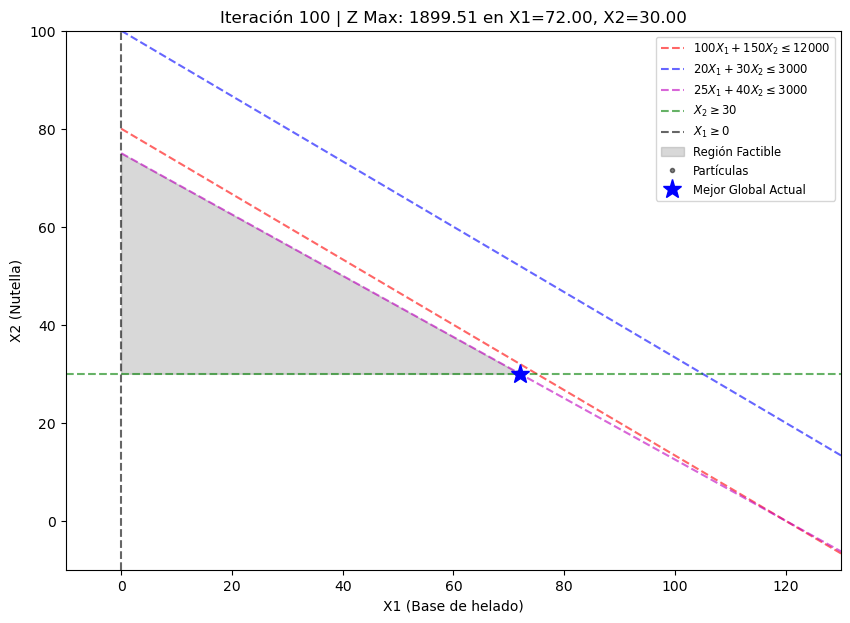

--- RESULTADO ÓPTIMO ENCONTRADO ---
X1 (Cantidad de Base): 72.0000 ml
X2 (Cantidad de Nutella): 30.0000 gr
Ganancia Máxima (Z): 1899.5099


In [4]:
np.random.seed(5)   # semilla fija para poder repetir exactamente esta corrida

# Parámetros del Enjambre
num_pob = 300          # cantidad de partículas
c1 = 0.5               # atracción hacia el mejor local (componente cognitiva)
c2 = 0.5               # atracción hacia el mejor global (componente social)
phi0 = 0.7             # Inercia: qué tanto conserva la partícula su velocidad anterior
generaciones = 100     # número de iteraciones

# Inicialización de población
x1p = np.random.uniform(0, 1000, num_pob)
x2p = np.random.uniform(0, 1000, num_pob)

# Variables para el mejor global y local
x1pg, x2pg = 0, 0      # posición del mejor global
fxpg = np.inf          # aptitud del mejor global: arranca en infinito para que cualquiera gane

x1pL = np.copy(x1p)    # mejor posición histórica de cada partícula
x2pL = np.copy(x2p)
fxpL = np.ones(num_pob) * fxpg

# Velocidades iniciales
vx1 = np.zeros(num_pob)
vx2 = np.zeros(num_pob)

# Preparación de la gráfica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(10, 7))

# Rango de X para dibujar las líneas de las restricciones
x_line = np.linspace(0, 150, 400)

for k in range(generaciones):
    # Ecuaciones de movimiento: inercia + jalón al mejor local + jalón al mejor global
    vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
    vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)

    # Nueva posición de cada partícula
    x1p = x1p + vx1
    x2p = x2p + vx2

    # Función Objetivo a MAXIMIZAR (negativa para que el PSO la minimice)
    z = -(16.9175 * x1p + 22.715 * x2p)

    # --- RESTRICCIONES (cada una escrita como g <= 0 y medida con max(0, g)) ---
    p1 = np.maximum(0, 100*x1p + 150*x2p - 12000)
    p2 = np.maximum(0, 20*x1p + 30*x2p - 3000)
    p3 = np.maximum(0, 25*x1p + 40*x2p - 3000)
    p4 = np.maximum(0, 30 - x2p)  # 0 X1 + 1 X2 >= 30
    p5 = np.maximum(0, -x1p)      # X1 >= 0
    p6 = np.maximum(0, -x2p)      # X2 >= 0

    # Función fitness con castigo altísimo (1e6) si violan restricciones
    fx = z + 1e6 * (p1**2 + p2**2 + p3**2 + p4**2 + p5**2 + p6**2)

    val = np.min(fx)    # mejor aptitud de esta generación
    ind = np.argmin(fx) # índice de la partícula que la tiene

    # Actualizar mejor global
    if val < fxpg:
        fxpg = val
        x1pg = x1p[ind]
        x2pg = x2p[ind]

    # Actualizar mejor local: solo las partículas que mejoraron su propio récord
    mejores = fx < fxpL
    fxpL[mejores] = fx[mejores]
    x1pL[mejores] = x1p[mejores]
    x2pL[mejores] = x2p[mejores]

    # ---------- GRAFICACIÓN ----------
    ax.clear()

    # 1. Dibujar las líneas de restricción, despejadas en función de X2
    y1 = (12000 - 100*x_line) / 150
    y2 = (3000 - 20*x_line) / 30
    y3 = (3000 - 25*x_line) / 40

    ax.plot(x_line, y1, 'r--', alpha=0.6, label=r"$100X_1 + 150X_2 \leq 12000$")
    ax.plot(x_line, y2, 'b--', alpha=0.6, label=r"$20X_1 + 30X_2 \leq 3000$")
    ax.plot(x_line, y3, 'm--', alpha=0.6, label=r"$25X_1 + 40X_2 \leq 3000$")
    ax.axhline(30, color='g', linestyle='--', alpha=0.6, label=r"$X_2 \geq 30$")
    ax.axvline(0, color='k', linestyle='--', alpha=0.6, label=r"$X_1 \geq 0$")

    # 2. Sombrear la región factible
    y_upper = np.minimum(y1, np.minimum(y2, y3)) # El techo es la restricción más estricta
    ax.fill_between(x_line, 30, y_upper, where=(y_upper >= 30), color='gray', alpha=0.3, label='Región Factible')

    # 3. Dibujar partículas y mejor global
    ax.plot(x1p, x2p, 'k.', alpha=0.5, label='Partículas')
    ax.plot(x1pg, x2pg, 'b*', markersize=14, label='Mejor Global Actual')

    # 4. Configuración del lienzo
    ax.set_xlim([-10, 130])
    ax.set_ylim([-10, 100])
    ax.set_xlabel('X1 (Base de helado)')
    ax.set_ylabel('X2 (Nutella)')
    ax.set_title(f'Iteración {k+1} | Z Max: {-fxpg:.2f} en X1={x1pg:.2f}, X2={x2pg:.2f}')
    ax.legend(loc='upper right', fontsize='small')

plt.show()

print("--- RESULTADO ÓPTIMO ENCONTRADO ---")
print(f"X1 (Cantidad de Base): {x1pg:.4f} ml")
print(f"X2 (Cantidad de Nutella): {x2pg:.4f} gr")
print(f"Ganancia Máxima (Z): {-fxpg:.4f}")

Estado final del enjambre. Las partículas se concentran en el vértice
$(72, 30)$, que es la esquina derecha de la región factible sombreada.

### 3.4 Pruebas y resultados

Se repite el mismo algoritmo, sin la parte de graficación, con 8 combinaciones de parámetros:
atracción ($c_1$, $c_2$), inercia ($\phi_0$), población e iteraciones. El caso 1 es el del
código de clase. Se considera que llegó al óptimo global si $Z$ queda a menos de 0.5 de
1899.51.

In [5]:
def pso_produccion(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para poder repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = np.random.uniform(0, 1000, num_pob)
    x2p = np.random.uniform(0, 1000, num_pob)

    x1pg, x2pg = 0, 0
    fxpg = np.inf
    x1pL, x2pL = np.copy(x1p), np.copy(x2p)
    fxpL = np.ones(num_pob) * fxpg
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
        vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)
        x1p = x1p + vx1
        x2p = x2p + vx2

        z = -(16.9175 * x1p + 22.715 * x2p)
        p1 = np.maximum(0, 100*x1p + 150*x2p - 12000)
        p2 = np.maximum(0, 20*x1p + 30*x2p - 3000)
        p3 = np.maximum(0, 25*x1p + 40*x2p - 3000)
        p4 = np.maximum(0, 30 - x2p)
        p5 = np.maximum(0, -x1p)
        p6 = np.maximum(0, -x2p)
        fx = z + 1e6 * (p1**2 + p2**2 + p3**2 + p4**2 + p5**2 + p6**2)

        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg = val, x1p[ind], x2p[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, -fxpg, np.array(historial), tiempo

# (numero, c1, c2, phi0, poblacion, iteraciones, descripcion)
casos_a = [
    (1, 0.5, 0.5, 0.7, 300, 100, "Base (codigo de clase)"),
    (2, 1.5, 1.5, 0.7, 300, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 300, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 300, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 300, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 300, 20, "Pocas iteraciones"),
    (8, 2.0, 0.5, 0.9, 50, 300, "Poblacion chica, corrida larga"),
]

z_optimo = 1899.51   # optimo analitico del problema

filas_a, historiales_a = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_a:
    x1_best, x2_best, z_best, historial, tiempo = pso_produccion(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_a[numero] = historial
    filas_a.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "X1": round(x1_best, 4), "X2": round(x2_best, 4),
        "Z": round(z_best, 4), "Error": round(abs(z_best - z_optimo), 4),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(z_best - z_optimo) <= 0.5 else "Se estanco",
    })

tabla_a = pd.DataFrame(filas_a)
tabla_a

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,X1,X2,Z,Error,Tiempo (ms),Resultado
0,1,Base (codigo de clase),0.5,0.5,0.7,300,100,72.0000,30.0000,1899.5099,0.0001,6.79,Optimo global
1,2,Atraccion alta,1.5,1.5,0.7,300,100,71.9913,30.0052,1899.4813,0.0287,7.41,Optimo global
2,3,Atraccion baja,0.1,0.1,0.7,300,100,71.9999,30.0000,1899.5099,0.0001,6.69,Optimo global
3,4,Inercia baja,0.5,0.5,0.4,300,100,72.0000,30.0000,1899.5099,0.0001,6.92,Optimo global
4,5,Inercia alta,0.5,0.5,0.9,300,100,71.6205,30.2337,1898.3988,1.1112,6.19,Se estanco
5,6,Poblacion pequeña,0.5,0.5,0.7,30,100,47.0335,45.6035,1831.5736,67.9364,5.06,Se estanco
6,7,Pocas iteraciones,0.5,0.5,0.7,300,20,69.8080,31.3052,1892.0762,7.4338,1.14,Se estanco
7,8,"Poblacion chica, corrida larga",2.0,0.5,0.9,50,300,71.2064,30.4235,1895.7032,3.8068,13.02,Se estanco


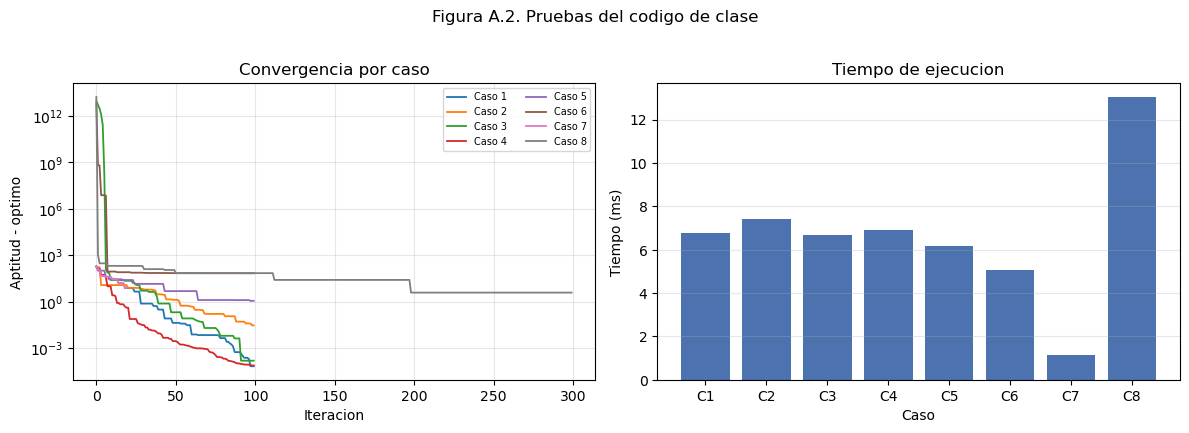

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Convergencia: distancia entre la aptitud del mejor global y el optimo, en escala log
for numero, historial in historiales_a.items():
    axes[0].semilogy(np.maximum(historial + z_optimo, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

# Tiempo de ejecucion de cada caso
axes[1].bar([f"C{n}" for n, *_ in casos_a], tabla_a["Tiempo (ms)"], color="#4C72B0")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura A.2. Pruebas del codigo de clase", y=1.02)
fig.tight_layout()
plt.show()

**Análisis:** En un problema lineal con restricciones el PSO es robusto: llega
al óptimo global con casi cualquier configuración razonable, y lo que decide es tener población
e iteraciones suficientes, no el ajuste fino de la inercia o de los coeficientes de
atracción.

## 3.5 Función Townsend modificada

### 3.5.1 Definición del problema

**Townsend modificada (función extra con restricción).** Minimizar

$$f(x,y) = -\left[\cos\big((x-0.1)y\big)\right]^2 - x\,\sin(3x+y)$$

sujeta a

$$x^2+y^2 < \left[2\cos t - \tfrac12\cos 2t - \tfrac14\cos 3t - \tfrac18\cos 4t\right]^2 + \left[2\sin t\right]^2,
\qquad t = \operatorname{atan2}(x,y)$$

con $-2.25 \le x \le 2.5$ y $-2.5 \le y \le 1.75$. Óptimo global conocido:
$f(2.0052938, 1.1944509) = -2.0239884$. 

## 3.5.2 Pseudocódigo

```
INICIO
  Definir num_pob, c1, c2, phi0, generaciones y los limites del dominio
  Inicializar x1p, x2p aleatorios dentro del dominio
  Inicializar vx1, vx2 en cero
  mejor_global <- particula con menor fitness de la poblacion inicial
  mejor_local  <- posicion inicial de cada particula

  PARA k = 1 HASTA generaciones
      vx1 <- phi0*vx1 + c1*rand*(x1pL - x1p) + c2*rand*(x1pg - x1p)
      vx2 <- phi0*vx2 + c1*rand*(x2pL - x2p) + c2*rand*(x2pg - x2p)
      x1p <- recortar(x1p + vx1, limites en x)
      x2p <- recortar(x2p + vx2, limites en y)

      z  <- -cos((x1p - 0.1)*x2p)^2 - x1p*sin(3*x1p + x2p)
      t  <- atan2(x1p, x2p)
      r2 <- (2cos t - 0.5cos 2t - 0.25cos 3t - 0.125cos 4t)^2 + (2 sin t)^2
      p1 <- max(0, x1p^2 + x2p^2 - r2)
      fx <- z + 1e6 * p1^2

      SI min(fx) < fxpg -> actualizar mejor global
      Actualizar mejor local de las particulas que mejoraron
      Dibujar region factible, particulas y mejor global
  FIN PARA

  Imprimir x, y y f del mejor global
FIN
```

Dos diferencias respecto al código de la Parte A, y por qué:

- El mejor global se toma de la población inicial en lugar de arrancar en $(0,0)$ con
  `fxpg = inf`. Aquí el origen es un punto cualquiera del dominio y arrastrar todo el enjambre
  hacia él en la primera iteración sesga la búsqueda.
- La posición se recorta al dominio. La función y la restricción solo están definidas en ese
  rectángulo, y sin el recorte la penalización al cuadrado se dispara.

### 3.5.3 Código

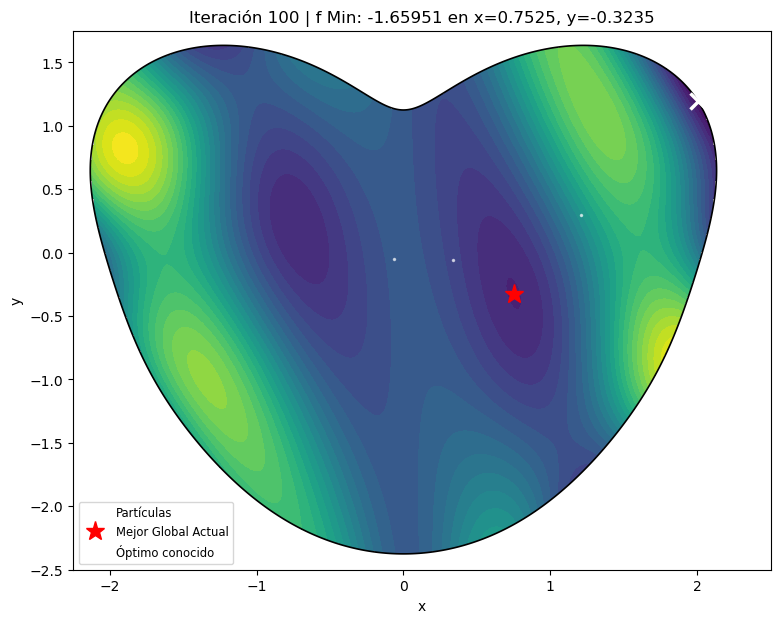

--- RESULTADO ÓPTIMO ENCONTRADO ---
x: 0.752526
y: -0.323520
f(x, y): -1.659511
Óptimo conocido: x=2.0052938, y=1.1944509, f=-2.0239884


In [7]:
np.random.seed(5)   # semilla fija para poder repetir esta corrida

# Parámetros del enjambre
num_pob_b = 300
c1_b = 0.5             # atracción al mejor local
c2_b = 0.5             # atracción al mejor global
phi0_b = 0.7           # inercia
generaciones_b = 100

# Límites del dominio de la función Townsend modificada
x_min, x_max = -2.25, 2.5
y_min, y_max = -2.5, 1.75

# Inicialización de la población dentro del dominio
x1p_b = np.random.uniform(x_min, x_max, num_pob_b)
x2p_b = np.random.uniform(y_min, y_max, num_pob_b)

# Velocidades iniciales
vx1_b = np.zeros(num_pob_b)
vx2_b = np.zeros(num_pob_b)


def fitness_townsend(x1p, x2p):
    """Devuelve (fitness penalizado, valor real de f). La restricción se castiga con 1e6."""
    # Función objetivo a MINIMIZAR
    z = -(np.cos((x1p - 0.1) * x2p))**2 - x1p * np.sin(3 * x1p + x2p)

    # Restricción: x^2 + y^2 < r(t)^2, con t = atan2(x, y) en ese orden
    t = np.arctan2(x1p, x2p)
    rx = 2*np.cos(t) - 0.5*np.cos(2*t) - 0.25*np.cos(3*t) - 0.125*np.cos(4*t)
    ry = 2*np.sin(t)
    p1 = np.maximum(0, x1p**2 + x2p**2 - (rx**2 + ry**2))

    return z + 1e6 * p1**2, z


# Mejores local y global tomados de la población inicial
fx_b, z_b = fitness_townsend(x1p_b, x2p_b)
x1pL_b, x2pL_b, fxpL_b = np.copy(x1p_b), np.copy(x2p_b), np.copy(fx_b)

ind = np.argmin(fx_b)
fxpg_b, x1pg_b, x2pg_b, zpg_b = fx_b[ind], x1p_b[ind], x2p_b[ind], z_b[ind]

# Malla para dibujar el contorno de la función y la frontera de la restricción
gx = np.linspace(x_min, x_max, 400)
gy = np.linspace(y_min, y_max, 400)
malla_x, malla_y = np.meshgrid(gx, gy)
malla_f = -(np.cos((malla_x - 0.1) * malla_y))**2 - malla_x * np.sin(3*malla_x + malla_y)
t_malla = np.arctan2(malla_x, malla_y)
rx_malla = (2*np.cos(t_malla) - 0.5*np.cos(2*t_malla)
            - 0.25*np.cos(3*t_malla) - 0.125*np.cos(4*t_malla))
malla_g = malla_x**2 + malla_y**2 - (rx_malla**2 + (2*np.sin(t_malla))**2)  # <= 0 es factible

# Preparación de la gráfica (sin animacion: se muestra la figura de la ultima iteracion)
fig, ax = plt.subplots(figsize=(9, 7))

for k in range(generaciones_b):
    # Ecuaciones de movimiento
    vx1_b = phi0_b * vx1_b + c1_b * np.random.rand(num_pob_b) * (x1pL_b - x1p_b) + c2_b * np.random.rand(num_pob_b) * (x1pg_b - x1p_b)
    vx2_b = phi0_b * vx2_b + c1_b * np.random.rand(num_pob_b) * (x2pL_b - x2p_b) + c2_b * np.random.rand(num_pob_b) * (x2pg_b - x2p_b)

    # Nueva posición, recortada al dominio de la función
    x1p_b = np.clip(x1p_b + vx1_b, x_min, x_max)
    x2p_b = np.clip(x2p_b + vx2_b, y_min, y_max)

    # Evaluación con penalización
    fx_b, z_b = fitness_townsend(x1p_b, x2p_b)

    val = np.min(fx_b)
    ind = np.argmin(fx_b)

    # Actualizar mejor global
    if val < fxpg_b:
        fxpg_b = val
        x1pg_b = x1p_b[ind]
        x2pg_b = x2p_b[ind]
        zpg_b = z_b[ind]

    # Actualizar mejor local
    mejores = fx_b < fxpL_b
    fxpL_b[mejores] = fx_b[mejores]
    x1pL_b[mejores] = x1p_b[mejores]
    x2pL_b[mejores] = x2p_b[mejores]

    # ---------- GRAFICACIÓN ----------
    ax.clear()

    # 1. Contorno de la función, dibujado solo dentro de la región factible
    ax.contourf(malla_x, malla_y, np.where(malla_g <= 0, malla_f, np.nan),
                levels=30, cmap='viridis')
    # 2. Frontera de la restricción
    ax.contour(malla_x, malla_y, malla_g, levels=[0], colors='k', linewidths=1.2)
    # 3. Partículas, mejor global y óptimo conocido
    ax.plot(x1p_b, x2p_b, 'w.', markersize=3, alpha=0.6, label='Partículas')
    ax.plot(x1pg_b, x2pg_b, 'r*', markersize=14, label='Mejor Global Actual')
    ax.plot(2.0052938, 1.1944509, 'wx', markersize=11, mew=2.5, label='Óptimo conocido')

    # 4. Configuración del lienzo
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Iteración {k+1} | f Min: {zpg_b:.5f} en x={x1pg_b:.4f}, y={x2pg_b:.4f}')
    ax.legend(loc='lower left', fontsize='small')

plt.show()

print("--- RESULTADO ÓPTIMO ENCONTRADO ---")
print(f"x: {x1pg_b:.6f}")
print(f"y: {x2pg_b:.6f}")
print(f"f(x, y): {zpg_b:.6f}")
print("Óptimo conocido: x=2.0052938, y=1.1944509, f=-2.0239884")

Estado final del enjambre sobre el contorno de la función. La zona
coloreada es la región factible y la línea negra es la frontera de la restricción.


### 3.5.3 Pruebas y resultados

Mismas 8 combinaciones de parámetros que en la Parte A, ahora sobre la Townsend modificada. Se
considera que llegó al óptimo global si $f$ queda a menos de $10^{-3}$ de $-2.0239884$.

In [8]:
def pso_townsend(num_pob, c1, c2, phi0, generaciones, semilla=5):
    """Mismo PSO de la celda anterior, sin graficación, para repetirlo con distintos parámetros."""
    np.random.seed(semilla)

    x1p = np.random.uniform(x_min, x_max, num_pob)
    x2p = np.random.uniform(y_min, y_max, num_pob)
    vx1, vx2 = np.zeros(num_pob), np.zeros(num_pob)

    fx, z = fitness_townsend(x1p, x2p)
    x1pL, x2pL, fxpL = np.copy(x1p), np.copy(x2p), np.copy(fx)
    ind = np.argmin(fx)
    fxpg, x1pg, x2pg, zpg = fx[ind], x1p[ind], x2p[ind], z[ind]

    historial = []
    inicio = time.perf_counter()

    for k in range(generaciones):
        vx1 = phi0 * vx1 + c1 * np.random.rand(num_pob) * (x1pL - x1p) + c2 * np.random.rand(num_pob) * (x1pg - x1p)
        vx2 = phi0 * vx2 + c1 * np.random.rand(num_pob) * (x2pL - x2p) + c2 * np.random.rand(num_pob) * (x2pg - x2p)
        x1p = np.clip(x1p + vx1, x_min, x_max)
        x2p = np.clip(x2p + vx2, y_min, y_max)

        fx, z = fitness_townsend(x1p, x2p)
        val, ind = np.min(fx), np.argmin(fx)
        if val < fxpg:
            fxpg, x1pg, x2pg, zpg = val, x1p[ind], x2p[ind], z[ind]

        mejores = fx < fxpL
        fxpL[mejores] = fx[mejores]
        x1pL[mejores] = x1p[mejores]
        x2pL[mejores] = x2p[mejores]

        historial.append(fxpg)

    tiempo = time.perf_counter() - inicio
    return x1pg, x2pg, zpg, np.array(historial), tiempo

casos_b = [
    (1, 0.5, 0.5, 0.7, 300, 100, "Base (mismos parametros de clase)"),
    (2, 1.5, 1.5, 0.7, 300, 100, "Atraccion alta"),
    (3, 0.1, 0.1, 0.7, 300, 100, "Atraccion baja"),
    (4, 0.5, 0.5, 0.4, 300, 100, "Inercia baja"),
    (5, 0.5, 0.5, 0.9, 300, 100, "Inercia alta"),
    (6, 0.5, 0.5, 0.7, 30, 100, "Poblacion pequeña"),
    (7, 0.5, 0.5, 0.7, 300, 20, "Pocas iteraciones"),
    (8, 2.0, 0.5, 0.9, 50, 300, "Poblacion chica, corrida larga"),
]

f_optimo = -2.0239884   # optimo global conocido

filas_b, historiales_b = [], {}

for numero, c1_p, c2_p, phi_p, pob_p, gen_p, descripcion in casos_b:
    x_best, y_best, f_best, historial, tiempo = pso_townsend(pob_p, c1_p, c2_p, phi_p, gen_p)
    historiales_b[numero] = historial
    filas_b.append({
        "Caso": numero, "Descripcion": descripcion,
        "c1": c1_p, "c2": c2_p, "phi0": phi_p,
        "Poblacion": pob_p, "Iteraciones": gen_p,
        "x": round(x_best, 4), "y": round(y_best, 4),
        "f": round(f_best, 6), "Error": round(abs(f_best - f_optimo), 6),
        "Tiempo (ms)": round(tiempo * 1000, 2),
        "Resultado": "Optimo global" if abs(f_best - f_optimo) <= 1e-2 else "Se estanco",
    })

tabla_b = pd.DataFrame(filas_b)
tabla_b

,Caso,Descripcion,c1,c2,phi0,Poblacion,Iteraciones,x,y,f,Error,Tiempo (ms),Resultado
0,1,Base (mismos parametros de clase),0.5,0.5,0.7,300,100,0.7525,-0.3235,-1.659511,0.364477,10.11,Se estanco
1,2,Atraccion alta,1.5,1.5,0.7,300,100,2.0056,1.1939,-2.023971,0.000017,10.70,Optimo global
2,3,Atraccion baja,0.1,0.1,0.7,300,100,2.0029,1.1987,-2.023897,0.000091,11.11,Optimo global
3,4,Inercia baja,0.5,0.5,0.4,300,100,0.7525,-0.3235,-1.659511,0.364477,9.01,Se estanco
4,5,Inercia alta,0.5,0.5,0.9,300,100,0.7525,-0.3235,-1.659511,0.364477,9.57,Se estanco
5,6,Poblacion pequeña,0.5,0.5,0.7,30,100,2.0160,1.1745,-2.022037,0.001952,5.80,Optimo global
6,7,Pocas iteraciones,0.5,0.5,0.7,300,20,0.7526,-0.3236,-1.659511,0.364477,1.87,Se estanco
7,8,"Poblacion chica, corrida larga",2.0,0.5,0.9,50,300,2.0002,1.2036,-2.023554,0.000434,18.82,Optimo global


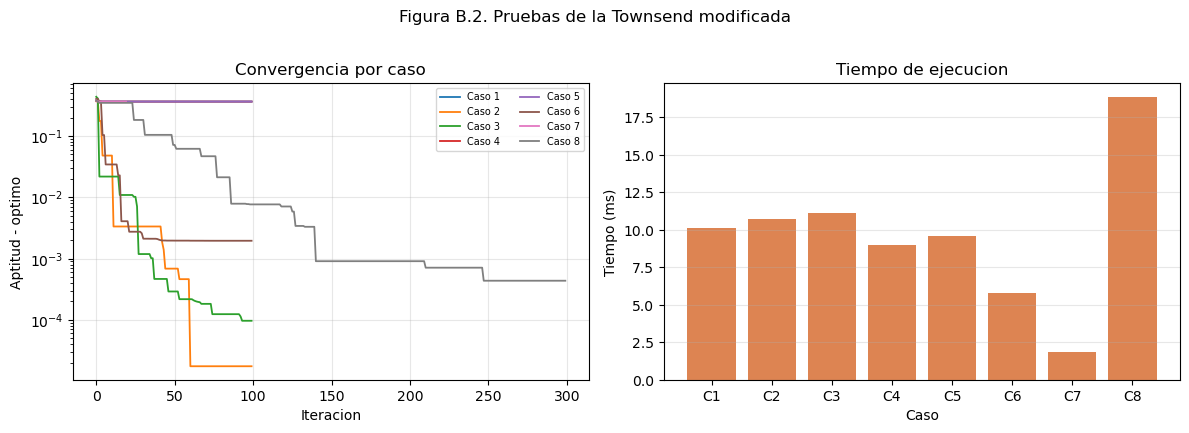

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for numero, historial in historiales_b.items():
    axes[0].semilogy(np.maximum(historial - f_optimo, 1e-12), lw=1.3, label=f"Caso {numero}")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Aptitud - optimo")
axes[0].set_title("Convergencia por caso")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].bar([f"C{n}" for n, *_ in casos_b], tabla_b["Tiempo (ms)"], color="#DD8452")
axes[1].set_xlabel("Caso")
axes[1].set_ylabel("Tiempo (ms)")
axes[1].set_title("Tiempo de ejecucion")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Figura B.2. Pruebas de la Townsend modificada", y=1.02)
fig.tight_layout()
plt.show()


**Análisis:** Aquí sí aparece el estancamiento. La corrida base termina en $f = -1.659511$ en
$(0.7525, -0.3235)$, que es un mínimo local: en la Figura B.1 se ve todo el enjambre colapsado
en ese punto, lejos del óptimo global marcado con la equis.

En una función multimodal con restricción no lineal el PSO
estándar no garantiza el óptimo global: con la misma configuración del código de clase se
estanca en un mínimo local. Conviene ejecutarlo varias veces con semillas o parámetros
distintos y quedarse con la mejor corrida, o agregar algún mecanismo que conserve diversidad,
como inercia decreciente o reinicio de las partículas estancadas.

### Conclusiones personales:

**Dayanni:** Con lo que vi en esta práctica, no diría que PSO es mejor que un algoritmo genético en general, ya que depende del problema. En el caso lineal, PSO converge rápido y con cualquier configuración razonable llega al vértice exacto, porque no hay mínimos locales donde atorarse. 

Donde sí se nota la diferencia es en Townsend, con los mismos parámetros de clase el enjambre se quedó atrapado en el mismo mínimo local en la mayoría de las corridas. Un PSO clásico no tiene mecanismo de mutación ni de diversidad forzada más allá de la inercia; una vez que el enjambre converge alrededor de un punto, ya no explora. Un algoritmo genético con mutación tiene, al menos en teoría, más chance de escapar de esa cuenca porque introduce variación aleatoria en cada generación independientemente de hacia dónde esté convergiendo la población.

Así que mi conclusión es que PSO es más simple de implementar y más rápido de ejecutar (menos operaciones por iteración que un GA con selección, cruce y mutación), pero es más sensible a quedarse estancado en problemas multimodales si no se ajustan bien los parámetros o no se corre varias veces. Un GA suele ser más robusto contra el estancamiento por diseño, a costa de ser más lento y de tener más parámetros que calibrar (tasa de mutación, tipo de cruce, tamaño de torneo, etc.).